Notebook 4: Evaluation of all repair methods

This notebook scores the stored repairs of five methods and compares them:

- **dictionary lookup**: each damaged word becomes the closest entry of a word list built from the excerpts
  outside the sample (edit distance, ties by frequency). No context, no model (notebook 2b).
- **BERT, no dictionary**: `bert-base-cased` fine-tuned on clean text, filling the slots left to right with a
  letter-similarity reranking of its own candidates (notebook 2). An ablation line: it shows what the
  dictionary candidates add.
- **BERT + dictionary**: the same model and reranking, with the 5 closest word-list entries of each damaged
  word added to BERT's candidates (notebook 2b). The main encoder method.
- **few-shot**: Qwen3 30B A3B Instruct with the instruction, 5 solved examples and the sentence with numbered
  slots (notebook 3).
- **few-shot + article**: the same with the whole article as context (notebook 3). Only compared with the
  LLM's own few-shot result: the other methods see the sentence only.

All methods get the same sentence (slot view) and are scored on exactly the same rows. The damaged text
itself ("no repair") is scored the same way as a reference.

**Input.** `data/processed/corrupted_v2.jsonl` (hash checked), the stored predictions in `runs/preds/`
(nothing is sent to a model here), `configs/llm.yaml`, `configs/bert_repair.yaml`,
`configs/bert_repair_lex.yaml` and `configs/lexicon.yaml` for the version names.

**Output.** The tables and the figure below.

`SPLIT` chooses the rows. It is `dev` here, where the numbers are used to fix the evaluation and are not the
result of the study. A method is scored only when all of its rows for the split are stored.

In [1]:
import hashlib
import json
import time

import pandas as pd
import transformers
from bert_score import BERTScorer

from blnrepair.data import ROOT, load_config
from blnrepair.evaluation import ci_long, paired_tests, resample_index, row_scores, wrong_fact_rate
from blnrepair.freeze import load_frozen
from blnrepair.bert_repair import load_repair_config, repair_version
from blnrepair.lexicon import lexicon_version, load_lexicon_config
from blnrepair.llm import load_llm_config, variant_versions
from blnrepair.plots import level_lines
from blnrepair.preds import load_preds, pred_path

transformers.logging.set_verbosity_error()
pd.set_option("display.max_colwidth", None)
config, llm_config = load_config(), load_llm_config()
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256
by_key = {(r["id"], r["severity"]): r for r in rows}
LEVELS = ["1w", "10", "25", "50", "75"]
SPLIT = "dev"

/Users/simonm/UniRGB_local/GenAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


What is scored

The rows are every row of the split that has slots (level 0 is the clean sentence), without the 5
sentences shown as few-shot examples: their gold answers are in the prompt. On the test split this leaves
nothing out, because the examples are dev sentences and dev and test share no excerpt. Below, how many rows
each method has stored.

In [2]:
example_ids = {i for i, _ in llm_config["fewshot_picks"]}
scored_rows = [r for r in rows if r["split"] == SPLIT and r["id"] not in example_ids and r["k"]]
scored_ids = sorted({r["id"] for r in scored_rows})
expected = {(r["id"], r["severity"]) for r in scored_rows}

versions = variant_versions(llm_config, SPLIT)
VARIANTS = {  # fixed order: a method keeps its colour in every figure
    "BERT + dictionary": ("bert_rerank", repair_version(load_repair_config(ROOT / "configs" / "bert_repair_lex.yaml"), SPLIT)),
    "few-shot": versions["few-shot"],
    "few-shot + article": versions["few-shot + article"],
    "dictionary lookup": ("lexicon", lexicon_version(load_lexicon_config(), SPLIT)),
    "BERT, no dictionary": ("bert_rerank", repair_version(load_repair_config(), SPLIT)),
}
ORDER = list(VARIANTS)
LLM = ["few-shot", "few-shot + article"]
stored = {name: {(p["id"], p["severity"]): p for p in load_preds(pred_path(*v))} for name, v in VARIANTS.items()}
available = [name for name in VARIANTS if expected <= set(stored[name])]
METHODS = available + ["no repair"]
print(f"{len(scored_ids)} sentences, {len(expected)} rows per method in the {SPLIT} split")
pd.DataFrame({"version": {n: f"{m}_{v}" for n, (m, v) in VARIANTS.items()},
              "rows stored": {n: len(expected & set(s)) for n, s in stored.items()},
              "rows needed": len(expected), "scored": {n: n in available for n in stored}})

15 sentences, 75 rows per method in the dev split


,version,rows stored,rows needed,scored
BERT + dictionary,bert_rerank_ftv1-l64-b5-n10-x5-dev,75,75,True
few-shot,llm_fewshot_v4-qwen3-30b-a3b-instruct-2507-exb46768-dev,75,75,True
few-shot + article,llm_fewshot_article_v3-qwen3-30b-a3b-instruct-2507-exb46768-dev,75,75,True
dictionary lookup,lexicon_v1-dev,75,75,True
"BERT, no dictionary",bert_rerank_ftv1-l8-b5-n10-dev,75,75,True


The scores

All scores are per sentence and level, over the damaged span unless stated (dossier §8). Primary:

- **BERTScore of the span**: F1 between the repaired span and the gold span, with `roberta-large` and the
  package's baseline rescaling (so unrelated text scores near 0 and identical text 1).
- **Fact Recovery Rate**: share of the span's fact tokens restored exactly in their slot (punctuation around
  the word ignored), averaged over sentences.
- **Anchor recovery**: whether the anchor fact is restored. The anchor is the same word at every level and is
  never dropped, so this is the cleanest series across levels (the share of facts among the damaged words
  falls as the span grows).

Secondary: Fact Recovery split into **visible** fact slots (some letters left) and **dropped** fact slots
(only context left), pooled over slots, because many sentences have no dropped fact; **exact words**;
**CER** of the span before and after repair and the **repair gain** (before minus after), all pooled per
level (all character edits over all gold characters), because on a one-word span a single wrong word can
give a sentence CER above 1, so a mean per sentence would be driven by the shortest spans; and **BERTScore
of the sentence**.

A format failure (the LLM answered with the wrong number of words) is scored as **no repair**: its slots
count as wrong, and its text is the damaged text. The LLM is also shown over its valid answers only.

In [3]:
def multiword_count(p):
    # LLM rows keep a dict with the positions of multi-word answers; BERT and lookup rows keep a list
    raw = json.loads(p["raw_output"]) if isinstance(p["raw_output"], str) else p["raw_output"]
    return len(raw["multiword"]) if isinstance(raw, dict) else 0


records = []
for name in available:
    for key in sorted(expected):
        p, row = stored[name][key], by_key[key]
        records.append({"method": name, "id": key[0], "level": key[1], "band": row["band"],
                        "multiword": multiword_count(p), **row_scores(row, p["pred_words"])})
for key in sorted(expected):
    records.append({"method": "no repair", "id": key[0], "level": key[1], "band": by_key[key]["band"],
                    "multiword": 0, **row_scores(by_key[key], None), "format_ok": True})
scores = pd.DataFrame(records)
scores["repair gain"] = scores["CER before"] - scores["CER after"]
scores["format failure"] = ~scores["format_ok"]

In [4]:
scorer = BERTScorer(model_type="roberta-large", lang="en", rescale_with_baseline=True)
t0 = time.perf_counter()
scores["BERTScore span"] = scorer.score(list(scores["repaired span"]), list(scores["gold span"]))[2].numpy()
gold_sentence = {r["id"]: r["gold_text"] for r in scored_rows}
scores["BERTScore sentence"] = scorer.score(list(scores["repaired sentence"]), [gold_sentence[i] for i in scores["id"]])[2].numpy()
print(f"BERTScore for {len(scores)} spans and sentences in {time.perf_counter() - t0:.0f} s")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6167.16it/s]

/Users/simonm/UniRGB_local/GenAI/.venv/lib/python3.11/site-packages/bert_score/scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self._baseline_vals = torch.from_numpy(


BERTScore for 450 spans and sentences in 91 s


Results with 95% confidence intervals

Every cell is the estimate with a 95% bootstrap interval. The sentence is the unit that is resampled
(10,000 resamples, percentile interval): the slots of one sentence share its context and are filled one after
another, so resampling single slots would treat them as independent and make the intervals too narrow.
Every method and level uses the same resampled sentence sets, and pooled rates are recomputed in every
resample.

In [5]:
N_BOOT = 10_000
index = resample_index(len(scored_ids), N_BOOT, seed=config["seed"])
ci = ci_long(scores, ["BERTScore span", "Fact Recovery Rate", "anchor recovery", "visible fact slots",
                      "dropped fact slots", "exact words", "CER before (pooled)", "CER after (pooled)",
                      "repair gain (pooled)", "BERTScore sentence"], scored_ids, index)
fmt = lambda r: "n/a" if pd.isna(r["value"]) else f"{r['value']:.2f} [{r['low']:.2f}, {r['high']:.2f}]"
ci["cell"] = ci.apply(fmt, axis=1)


def ci_table(metric, methods=METHODS):
    return ci[ci["metric"] == metric].pivot(index="level", columns="method", values="cell").reindex(index=LEVELS, columns=methods)


for metric in ["BERTScore span", "Fact Recovery Rate", "anchor recovery"]:
    print(metric)
    display(ci_table(metric))

BERTScore span


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",no repair
level,,,,,,
1w,"0.85 [0.72, 0.95]","0.86 [0.75, 0.96]","0.90 [0.79, 0.99]","0.73 [0.58, 0.87]","0.59 [0.47, 0.72]","0.34 [0.19, 0.48]"
10,"0.71 [0.59, 0.82]","0.65 [0.49, 0.81]","0.63 [0.46, 0.80]","0.48 [0.33, 0.61]","0.38 [0.26, 0.52]","0.01 [-0.08, 0.11]"
25,"0.48 [0.36, 0.60]","0.45 [0.32, 0.59]","0.55 [0.42, 0.68]","0.43 [0.34, 0.52]","0.16 [0.08, 0.23]","-0.16 [-0.23, -0.09]"
50,"0.44 [0.33, 0.55]","0.44 [0.29, 0.56]","0.42 [0.24, 0.59]","0.44 [0.37, 0.52]","0.14 [0.08, 0.20]","-0.27 [-0.30, -0.23]"
75,"0.43 [0.35, 0.51]","0.17 [-0.04, 0.39]","0.26 [0.02, 0.49]","0.40 [0.33, 0.47]","-0.03 [-0.13, 0.05]","-0.34 [-0.38, -0.30]"


Fact Recovery Rate


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",no repair
level,,,,,,
1w,"0.60 [0.33, 0.87]","0.60 [0.33, 0.87]","0.73 [0.53, 0.93]","0.40 [0.13, 0.67]","0.13 [0.00, 0.33]","0.00 [0.00, 0.00]"
10,"0.63 [0.40, 0.83]","0.47 [0.27, 0.70]","0.50 [0.27, 0.73]","0.42 [0.20, 0.65]","0.17 [0.00, 0.37]","0.00 [0.00, 0.00]"
25,"0.51 [0.31, 0.71]","0.42 [0.23, 0.62]","0.57 [0.36, 0.77]","0.41 [0.22, 0.61]","0.09 [0.00, 0.19]","0.00 [0.00, 0.00]"
50,"0.50 [0.32, 0.68]","0.46 [0.28, 0.65]","0.50 [0.31, 0.69]","0.47 [0.29, 0.66]","0.05 [0.00, 0.11]","0.00 [0.00, 0.00]"
75,"0.49 [0.30, 0.68]","0.37 [0.20, 0.57]","0.42 [0.24, 0.61]","0.44 [0.26, 0.63]","0.04 [0.00, 0.08]","0.00 [0.00, 0.00]"


anchor recovery


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",no repair
level,,,,,,
1w,"0.60 [0.33, 0.87]","0.60 [0.33, 0.87]","0.73 [0.53, 0.93]","0.40 [0.13, 0.67]","0.13 [0.00, 0.33]","0.00 [0.00, 0.00]"
10,"0.60 [0.33, 0.87]","0.40 [0.13, 0.67]","0.40 [0.13, 0.67]","0.40 [0.13, 0.67]","0.13 [0.00, 0.33]","0.00 [0.00, 0.00]"
25,"0.60 [0.33, 0.87]","0.47 [0.20, 0.73]","0.53 [0.27, 0.80]","0.40 [0.13, 0.67]","0.13 [0.00, 0.33]","0.00 [0.00, 0.00]"
50,"0.53 [0.27, 0.80]","0.47 [0.20, 0.73]","0.47 [0.20, 0.73]","0.40 [0.13, 0.67]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
75,"0.53 [0.27, 0.80]","0.40 [0.13, 0.67]","0.40 [0.13, 0.67]","0.40 [0.13, 0.67]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"


Secondary scores, same layout. "CER before" is the same for every method (it is the damaged text), so it is
shown once, in the "no repair" column.

In [6]:
print("fact slots per level (the same for every method)")
display(scores[scores["method"] == "no repair"].groupby("level")[["visible facts", "dropped facts"]].sum().reindex(LEVELS).T)
for metric in ["visible fact slots", "dropped fact slots", "exact words", "CER after (pooled)", "repair gain (pooled)",
               "BERTScore sentence"]:
    print(metric)
    display(ci_table(metric, available if metric in ["repair gain (pooled)"] else METHODS))
print("CER before (pooled)")
display(ci_table("CER before (pooled)", ["no repair"]))

fact slots per level (the same for every method)


level,1w,10,25,50,75
visible facts,15,23,30,39,46
dropped facts,0,1,2,2,5


visible fact slots


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",no repair
level,,,,,,
1w,"0.60 [0.33, 0.87]","0.60 [0.33, 0.87]","0.73 [0.53, 0.93]","0.40 [0.13, 0.67]","0.13 [0.00, 0.33]","0.00 [0.00, 0.00]"
10,"0.65 [0.45, 0.84]","0.52 [0.32, 0.71]","0.57 [0.33, 0.76]","0.43 [0.23, 0.65]","0.22 [0.00, 0.43]","0.00 [0.00, 0.00]"
25,"0.50 [0.31, 0.70]","0.40 [0.24, 0.59]","0.53 [0.34, 0.74]","0.43 [0.27, 0.62]","0.13 [0.00, 0.27]","0.00 [0.00, 0.00]"
50,"0.49 [0.32, 0.67]","0.38 [0.22, 0.58]","0.44 [0.25, 0.64]","0.46 [0.31, 0.63]","0.08 [0.00, 0.15]","0.00 [0.00, 0.00]"
75,"0.50 [0.33, 0.68]","0.33 [0.18, 0.51]","0.39 [0.22, 0.58]","0.46 [0.31, 0.63]","0.07 [0.00, 0.12]","0.00 [0.00, 0.00]"


dropped fact slots


...

method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary"
level,,,,,
1w,"0.16 [0.08, 0.23]","0.11 [-0.03, 0.22]","0.12 [-0.05, 0.25]","0.01 [-0.10, 0.12]","-0.24 [-0.36, -0.13]"
10,"0.17 [0.13, 0.20]","0.09 [0.04, 0.16]","0.10 [0.02, 0.17]","0.07 [0.01, 0.12]","-0.16 [-0.31, -0.02]"
25,"0.14 [0.10, 0.17]","0.08 [0.03, 0.13]","0.06 [-0.00, 0.13]","0.09 [0.06, 0.13]","-0.28 [-0.38, -0.17]"
50,"0.15 [0.11, 0.18]","0.07 [-0.02, 0.13]","0.08 [0.05, 0.12]","0.12 [0.10, 0.13]","-0.29 [-0.36, -0.23]"
75,"0.13 [0.11, 0.15]","0.08 [0.04, 0.12]","0.06 [0.02, 0.11]","0.11 [0.09, 0.13]","-0.35 [-0.45, -0.27]"


BERTScore sentence


method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary",no repair
level,,,,,,
1w,"0.98 [0.97, 1.00]","0.99 [0.98, 1.00]","0.99 [0.98, 1.00]","0.97 [0.95, 0.99]","0.96 [0.94, 0.97]","0.91 [0.88, 0.94]"
10,"0.94 [0.92, 0.97]","0.94 [0.92, 0.97]","0.94 [0.91, 0.97]","0.90 [0.87, 0.92]","0.89 [0.86, 0.92]","0.78 [0.75, 0.82]"
25,"0.83 [0.77, 0.88]","0.81 [0.76, 0.86]","0.84 [0.77, 0.90]","0.80 [0.76, 0.84]","0.68 [0.64, 0.72]","0.51 [0.47, 0.54]"
50,"0.68 [0.61, 0.74]","0.65 [0.52, 0.74]","0.64 [0.50, 0.77]","0.67 [0.63, 0.71]","0.47 [0.43, 0.51]","0.19 [0.14, 0.23]"
75,"0.55 [0.49, 0.61]","0.33 [0.14, 0.51]","0.40 [0.19, 0.59]","0.52 [0.47, 0.57]","0.17 [0.09, 0.24]","-0.10 [-0.14, -0.06]"


CER before (pooled)


method,no repair
level,
1w,"0.27 [0.23, 0.30]"
10,"0.30 [0.26, 0.35]"
25,"0.29 [0.26, 0.33]"
50,"0.30 [0.27, 0.33]"
75,"0.30 [0.28, 0.33]"


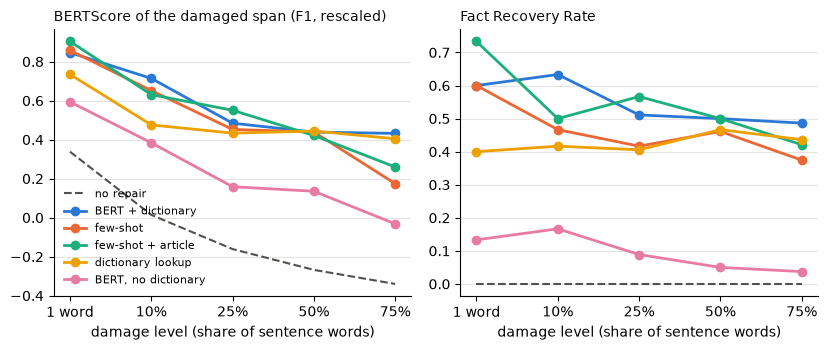

In [7]:
means = ci[ci["metric"].isin(["BERTScore span", "Fact Recovery Rate"])].pivot_table(
    index=["method", "level"], columns="metric", values="value").reindex(pd.MultiIndex.from_product([METHODS, LEVELS]))
fig = level_lines(means, ["BERTScore span", "Fact Recovery Rate"],
                  ["BERTScore of the damaged span (F1, rescaled)", "Fact Recovery Rate"], ORDER)

Format failures and the LLM over valid answers only

Format failures per level (a format failure is scored as no repair), and the LLM's scores over the rows
with a valid answer only. The valid-only scores show whether a difference between the LLM and the other
methods comes from better or worse repairs or only from the answers that could not be read.

In [8]:
llm_scored = [m for m in LLM if m in available]
failures = scores[scores["method"].isin(llm_scored)].pivot_table(index="level", columns="method", values="format failure",
                                                                 aggfunc="sum").reindex(index=LEVELS, columns=llm_scored)
failures.loc["all"] = failures.sum()
print(f"format failures per level (of {len(scored_ids)} sentences per level); multi-word answers: "
      f"{scores.groupby('method')['multiword'].sum().reindex(llm_scored).to_dict()}")
display(failures)
valid = scores[scores["method"].isin(llm_scored) & scores["format_ok"]]
valid.groupby(["level", "method"])[["BERTScore span", "fact recovery", "anchor ok"]].agg(["mean", "size"]) \
    .reindex(pd.MultiIndex.from_product([LEVELS, llm_scored])).round(3)

format failures per level (of 15 sentences per level); multi-word answers: {'few-shot': 1, 'few-shot + article': 0}


method,few-shot,few-shot + article
level,,
1w,0,0
10,0,0
25,1,0
50,1,2
75,5,5
all,7,7


BERTScore span      fact recovery      anchor ok     
                                mean size          mean size      mean size
1w few-shot                    0.858   15         0.600   15     0.600   15
   few-shot + article          0.903   15         0.733   15     0.733   15
10 few-shot                    0.652   15         0.467   15     0.400   15
   few-shot + article          0.631   15         0.500   15     0.400   15
25 few-shot                    0.481   14         0.446   14     0.500   14
   few-shot + article          0.550   15         0.567   15     0.533   15
50 few-shot                    0.495   14         0.494   14     0.500   14
   few-shot + article          0.529   13         0.577   13     0.538   13
75 few-shot                    0.445   10         0.562   10     0.600   10
   few-shot + article          0.574   10         0.632   10     0.600   10

Paired tests

Every sentence is repaired at every level by every method, so methods are compared sentence by sentence.
Only two comparisons are tested, each for a hypothesis stated before the test run; all other comparisons are
shown descriptively below, with the intervals above:

- **BERT + dictionary against few-shot** (H2, SQ2): the best encoder method against the LLM, with the same
  input.
- **few-shot against dictionary lookup** (H2b): does the GenAI method beat a plain dictionary lookup? The
  LLM is used here, not BERT + dictionary, because BERT + dictionary contains the lookup itself.

Per level, **McNemar's exact test** on anchor recovery (a yes or no per sentence, paired: only sentences
where exactly one method restores the anchor count) and the **Wilcoxon signed-rank test** on span BERTScore
(paired, bounded and skewed scores, so no normality is assumed; sentences with equal scores are left out).
The p-values of each test are **Holm-adjusted** over the 2 pairs and 5 levels together (10 tests per family),
which controls the chance of any false positive without assuming the tests are independent.

In [9]:
PAIRS = [("BERT + dictionary", "few-shot"), ("few-shot", "dictionary lookup")]
if all(m in available for pair in PAIRS for m in pair):
    tests = paired_tests(scores, PAIRS, LEVELS, scored_ids)
    display(tests.round(4))
else:
    print("paired tests: not all methods have a complete run")

,first,second,level,anchor: first only,anchor: second only,McNemar p,BERTScore: first higher,BERTScore: second higher,Wilcoxon p,McNemar p (Holm),Wilcoxon p (Holm)
0,BERT + dictionary,few-shot,1w,2,2,1.0000,3,2,0.6858,1.0,1.0000
1,BERT + dictionary,few-shot,10,5,2,0.4531,8,6,0.3003,1.0,1.0000
2,BERT + dictionary,few-shot,25,4,2,0.6875,8,7,0.6788,1.0,1.0000
3,BERT + dictionary,few-shot,50,3,2,1.0000,8,7,0.7197,1.0,1.0000
4,BERT + dictionary,few-shot,75,4,2,0.6875,10,5,0.0730,1.0,0.7300
5,few-shot,dictionary lookup,1w,4,1,0.3750,4,3,0.2367,1.0,1.0000
6,few-shot,dictionary lookup,10,3,3,1.0000,10,5,0.1205,1.0,0.9644
7,few-shot,dictionary lookup,25,4,3,1.0000,9,6,0.6387,1.0,1.0000
8,few-shot,dictionary lookup,50,4,3,1.0000,7,8,0.8904,1.0,1.0000
9,few-shot,dictionary lookup,75,4,4,1.0000,5,10,0.0833,1.0,0.7493


**Descriptive paired comparisons.** The mean difference (first minus second) and how many sentences were
better, equal or worse. **BERT + dictionary against dictionary lookup** shows what BERT's context adds to the
letters; **BERT + dictionary against BERT, no dictionary** what the dictionary candidates add; **few-shot +
article against few-shot** whether the article helps the LLM.

In [10]:
def paired(a, b, metric):
    wide = scores[scores["method"].isin([a, b])].pivot_table(index=["level", "id"], columns="method", values=metric)
    diff = (wide[a] - wide[b]).rename("diff").reset_index()
    return diff.groupby("level").agg(mean_diff=("diff", "mean"), better=("diff", lambda d: (d > 1e-9).sum()),
                                     same=("diff", lambda d: (d.abs() <= 1e-9).sum()),
                                     worse=("diff", lambda d: (d < -1e-9).sum())).reindex(LEVELS)


for a, b in [("BERT + dictionary", "dictionary lookup"), ("BERT + dictionary", "BERT, no dictionary"),
             ("few-shot + article", "few-shot")]:
    if {a, b} <= set(available):
        print(f"{a} against {b}")
        display(pd.concat({m: paired(a, b, m) for m in ["BERTScore span", "fact recovery"]}, axis=1).round(3))

BERT + dictionary against dictionary lookup


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.111      4    9     2         0.200      3   12     0
10             0.239     10    4     1         0.217      5   10     0
25             0.051      8    2     5         0.106      4    9     2
50            -0.005      8    0     7         0.033      4    8     3
75             0.028      9    0     6         0.050      4    8     3

BERT + dictionary against BERT, no dictionary


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.253     10    3     2         0.467      7    8     0
10             0.330     13    0     2         0.467      8    7     0
25             0.326     13    0     2         0.422      9    6     0
50             0.303     12    0     3         0.450     11    4     0
75             0.464     15    0     0         0.449     11    4     0

few-shot + article against few-shot


BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.046      3   11     1         0.133      3   11     1
10            -0.021      6    5     4         0.033      2   12     1
25             0.098      9    0     6         0.150      6    7     2
50            -0.018      7    2     6         0.039      3   11     1
75             0.086      7    5     3         0.047      3   12     0

Does span BERTScore see the fact? (SQ3)

For each method and level: the chance that a repair with the **wrong** anchor gets at least as high a span
BERTScore as a repair with the **right** anchor (all pairs of one such repair each; equal scores count
half). 0 means BERTScore always ranks the right fact higher; 0.5 means BERTScore does not see the fact at
all. This is 1 minus the AUC of BERTScore as a detector of a correct anchor. It needs no threshold, so
there is nothing to choose on dev: the two reference points are fixed. It is computed per method, because
pooling methods would mix the difference between methods into it. At the one-word level the span is the
anchor alone, so the value must be near 0 there (a check of the code). "n/a" means that the method got the
anchor right in every sentence or in none.

In [11]:
repaired = scores[scores["method"].isin(available)]
sq3 = repaired.groupby(["level", "method"]).apply(
    lambda g: pd.Series({"wrong-fact rate": wrong_fact_rate(g["BERTScore span"], g["anchor ok"]),
                         "anchor wrong": int((~g["anchor ok"]).sum())}), include_groups=False)
sq3["wrong-fact rate"].unstack("method").reindex(index=LEVELS, columns=available).round(2)

method,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary"
level,,,,,
1w,0.00,0.00,0.00,0.00,0.00
10,0.46,0.11,0.04,0.31,0.00
25,0.70,0.45,0.48,0.65,0.12
50,0.54,0.38,0.32,0.59,NaN
75,0.36,0.13,0.15,0.46,NaN


By level and length band (BERTScore of the span, mean): separates the share of damaged words from the
absolute length of the damaged span.

In [12]:
scores.pivot_table(index="level", columns=["band", "method"], values="BERTScore span", aggfunc="mean") \
      .reindex(index=LEVELS).round(2)

band               20-29                                                 \
method BERT + dictionary BERT, no dictionary dictionary lookup few-shot   
level                                                                     
1w                  0.95                0.57              0.86     0.89   
10                  0.82                0.49              0.65     0.81   
25                  0.42                0.15              0.40     0.35   
50                  0.41                0.14              0.48     0.42   
75                  0.44                0.00              0.43     0.14   

band                                            30-44                      \
method few-shot + article no repair BERT + dictionary BERT, no dictionary   
level                                                                       
1w                   0.92      0.25              0.77                0.69   
10                   0.70      0.07              0.59                0.29   
25                   0.52     -0.10              0.57                0.14   
50                   0.38     -0.24              0.48                0.13   
75                   0.34     -0.29              0.43               -0.08   

band                                                            \
method dictionary lookup few-shot few-shot + article no repair   
level                                                            
1w                  0.61     0.87               0.95      0.45   
10                  0.29     0.46               0.51     -0.04   
25                  0.51     0.56               0.63     -0.21   
50                  0.43     0.56               0.59     -0.29   
75                  0.40     0.23               0.19     -0.37   

band               45-60                                                 \
method BERT + dictionary BERT, no dictionary dictionary lookup few-shot   
level                                                                     
1w                  0.70                0.37              0.69     0.71   
10                  0.72                0.30              0.44     0.68   
25                  0.43                0.23              0.34     0.49   
50                  0.42                0.12              0.36     0.13   
75                  0.41                0.00              0.32     0.13   

band                                 
method few-shot + article no repair  
level                                
1w                   0.71      0.29  
10                   0.74     -0.03  
25                   0.42     -0.23  
50                   0.06     -0.31  
75                   0.20     -0.40

**Contamination probe.** The share of near-verbatim continuations of the LLM's probe (notebook 3): a high
share would mean the LLM results may be inflated.

In [13]:
probe = pd.DataFrame([json.loads(p["raw_output"]) for p in load_preds(pred_path(*versions["probe"]))])
if len(probe):
    print(f"probe on {len(probe)} {SPLIT} sentences: {probe['near_verbatim'].sum()} near-verbatim "
          f"({probe['near_verbatim'].mean():.0%}); similarity median {probe['similarity'].median():.2f}, max {probe['similarity'].max():.2f}")
else:
    print(f"no probe stored for {SPLIT}")

probe on 20 dev sentences: 0 near-verbatim (0%); similarity median 0.25, max 0.31


Manual check

18 repairs (6 sentences at levels 10, 25 and 50), drawn with the project seed, for reading by hand, to find
repairs that are fluent but wrong.

In [14]:
rank = lambda i: hashlib.sha256(f"{config['seed']}-manual-{i}".encode()).hexdigest()
manual_ids = sorted(scored_ids, key=rank)[:6]
look = scores[scores["id"].isin(manual_ids) & scores["level"].isin(["10", "25", "50"])]
look.pivot_table(index=["id", "level", "gold span", "damaged span"], columns="method", values="repaired span", aggfunc="first") \
    [available].reset_index().drop(columns="id")

method,level,gold span,damaged span,BERT + dictionary,few-shot,few-shot + article,dictionary lookup,"BERT, no dictionary"
0,10,"No. 12, Market-place, Oxford-street, on","Uo. NIaruet-plece, Oforcl-sbteet, an","No. 5 Market-place, force-street, an","No. of Marlborough-place, Oxford-street, and","No. at Marylebone, Oxford-street, and","to. Dorset-place, Oxford-street, an","No. 5 Easts-place, Oxford-street, on"
1,25,"occupier of a house, No. 12, Market-place, Oxford-street, on the site of the","ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af","occupied ot the house, No. 9 Market-place, force-street, an the state of the","occupant of the house, Uo. of Marlet-place, Oxford-street, and the site of the","occupier of the house, No. of Marlborough-place, Oxford-street, and the site of the","occupied ot house, to. Dorset-place, Oxford-street, an the she of","house of a coner, No. 9 ands-place, Oxford-street, and that it was the"
2,50,"years past the prisoner was the occupier of a house, No. 12, Market-place, Oxford-street, on the site of the old Oxford-street Market, and complaints were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","years past he prisoner was the occupied ot the house, No. 9 Market-place, force-street, an the state of health of Alford-street Market, andquiries conspiring were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","years past the prisoner was the occupied ot house, to. Dorset-place, Oxford-street, an the she of Oxford-street Market, complaint","years past he wased ined to the post of theroner, No. 9 ands-lane, Cromwell-street, and the same inquiry was madelyrned on-Thursday last, and noquiries were"
3,10,"mother, Ellen Bean.","mather, Elen Besn.","father, Ellen Ben.","mother, Ellen Benson.","mother, Ellen Beane.","mother, Ellen Best.","father, John Beau."
4,25,"bank notes from his mother, Ellen Bean.","bana trom hi mather, Elen Besn.","bank money from his father, Ellen Ben.","bana trom hi mather, Elen Besn.","bank notes from his mother, Eleanor Beane.","bank from he mother, Ellen Best.","a publichouse atrom s se, Pen green."
5,50,"tried and convicted of stealing £140 in bank notes from his mother, Ellen Bean.","trled ald ef stoalinb £l40 ii bana trom hi mather, Elen Besn.","tried and sentencedmand of stealing £40 in bank from from his father, Ellen Ben.","tried said that he was £stealing £140 in the from his mother, Elen Benson.","tried and found guilty of £stealing £140 in the from his mother, Elen Beau.","tried and of stealing £40 in bank from he mother, Ellen Best.","charged with havingelonio andnionio stealing £10 in a publichouse atrom s thee, aten street."
6,10,"bicycle for £2, and","icyclc tor £1, aud","bicycle for £1, and","bicycle for £100, and","bicycle for £1, and","bicycle to £1, and","bicycless for £1s, and"
7,25,"sold the bicycle for £2, and then came to","so1d tbe icyclc tor £1, aud bhen eame bo","sold the bicycle for £1, and then came to","sold the cycle for £1, and then came to","sold the bicycle for £1, and then came to","sold the bicycle to £1, and been came to","had been inly worth £1s, and then wased to"
8,50,"where, it was asserted, he sold the bicycle for £2, and then came to London with the money.","It wae assetod, e so1d tbe icyclc tor £1, aud bhen eame bo Loidou witb tbe nioney.","where It was asserted, he sold the bicycle for £1, and then came to London with the money.","and it was assessed, he sold the bicycle for £1, and then came to London with the money.","and it was assessed, he sold the bicycle for £1, and then came to London with the money.","It was asserted, a sold the bicycle to £1, and been came to London with the money.","where he was aed, and had been fi